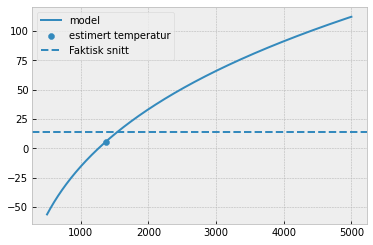

In [1]:
import numpy as np
import matplotlib.pyplot as plt

'''
Skal implementer delta*T_j**4 = 1/4I der I = P_sol/(4pir**2)

lage en graf som modellerer P_sol mot Tj, altså gitt en solintensitet,
vis temperatur
'''

# Parametere som omhandler jordens klima
Itrue = 1370 # W/m^2
albedo_true = 0.3 # https://earthobservatory.nasa.gov/images/84499/measuring-earths-albedo
EarthAverage = 13.9 

# Parametere som er generelle
Kelvin = -273.15
delta = 5.670374*10**(-8) # W/(m**2K**2) https://en.wikipedia.org/wiki/Stefan%E2%80%93Boltzmann_law

# Begynn koding

def T(i):
    # Returnerer i celsius
    return np.sqrt(np.sqrt(i/(4*delta))) + Kelvin

Is = np.linspace(500, 5000, 1000)

plt.style.use('bmh')
plt.plot(Is, T(Is), label='model') # lager linjen
plt.scatter(Itrue, T(Itrue), label='estimert temperatur') # plotter punktet med estimert snitt temperatur
plt.axhline(y = EarthAverage, linestyle = '--', label='Faktisk snitt') #plotter faktisk snitt temperatur
plt.legend()
plt.show()


# Jorden med albedo

$$ \delta T^4_j + \frac{1}{4}I\alpha = \frac{1}{4}I$$

Vi vil da lage en funksjon som tar albedo som parameter og returnerer estimert snitttemperatur til jorden. Løser med hensyn på T

$$ T_j = \left( \frac{I - I\alpha}{4\delta} \right)^{1/4}  $$

In [2]:
def T_with_albedo(alpha, I=Itrue):
    return ((I - I*alpha)/(4*delta))**0.25 + Kelvin

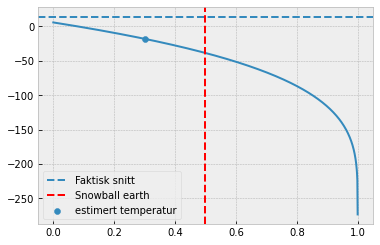

In [3]:
alphas = np.linspace(0,1,1000)

plt.plot(alphas, T_with_albedo(alphas))
plt.axhline(y = EarthAverage, linestyle = '--', label='Faktisk snitt') #plotter faktisk snitt temperatur
plt.axvline(x=0.5, linestyle = '--',c='red', label='Snowball earth')
plt.scatter(albedo_true, T_with_albedo(albedo_true), label='estimert temperatur') # plotter punktet med estimert snitt temperatur

plt.legend()
plt.show()

Denne modellen er mer presis, men mindre nøyaktig.
https://www.eea.europa.eu/data-and-maps/figures/antarctic-temperature-change-and-atmospheric-carbon-dioxide-concentration-co2-over-the-past-800-000-years

In [4]:
print(f'Målt temperatur : {EarthAverage: .2f} C°')
print(f'Estimert temperatur som sort legeme: {T(Itrue): .2f} C°')
print(f'Estimert temperatur med albedo: {T_with_albedo(albedo_true): .2f} C°')


Målt temperatur :  13.90 C°
Estimert temperatur som sort legeme:  5.63 C°
Estimert temperatur med albedo: -18.15 C°


# Med drivhuseffekt

$$ \delta T_j^4 + \frac{1}{4}I\alpha =\frac{1}{4}I + \delta T_a^4 $$
$$  2\delta T_a^4 =  \delta T_j^4 \to \delta T_a^4 =  \frac{1}{2}\delta T_j^4 $$

$$ \delta T_j^4 + \frac{1}{4}I\alpha =\frac{1}{4}I + \frac{1}{2}\delta T_j^4  $$
Løser med hensyn på $T_j$:

$$ \delta T_j^4 - \frac{1}{2}\delta T_j^4  =\frac{1}{4}I - \frac{1}{4}I\alpha $$
$$ \frac{1}{2}\delta T_j^4  =\frac{I-I\alpha}{4} $$
$$ T_j^4  =\frac{I-I\alpha}{2\delta} $$
$$ T_j =\left(\frac{I-I\alpha}{2\delta}\right)^{1/4} $$

In [5]:
def T_with_albedo_and_green(alpha, I=Itrue):
    return ((I - I*alpha)/(2*delta))**0.25 + Kelvin

In [14]:
from scipy import optimize

def f(x):
    return T_with_albedo_and_green(x) - EarthAverage

albedo_est = optimize.newton(f, 0.43)
print(albedo_est)

0.4379805600320552


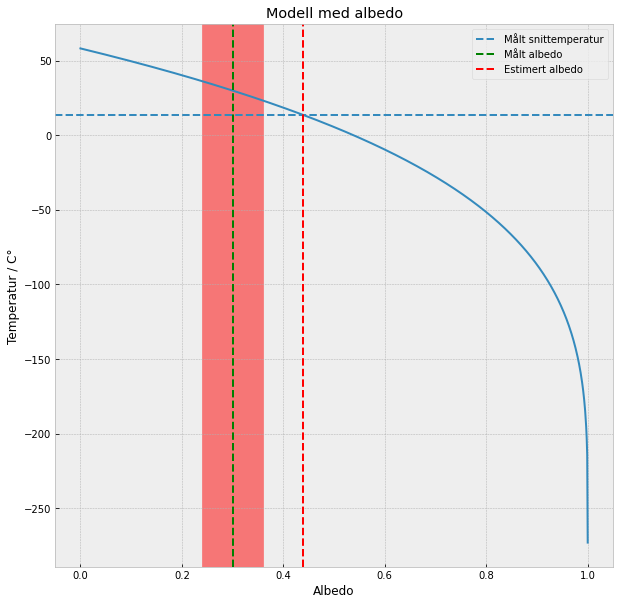

In [18]:
plt.figure(figsize=(10,10))
plt.plot(alphas, T_with_albedo_and_green(alphas))
plt.axhline(y = EarthAverage, linestyle = '--', label='Målt snittemperatur') #plotter faktisk snitt temperatur
#plt.axvline(x=0.5, linestyle = '--',c='red', label='Snowball earth')
#plt.scatter(albedo_true, T_with_albedo_and_green(albedo_true), label='estimert temperatur') # plotter punktet med estimert snitt temperatur
plt.axvline(x=albedo_true, linestyle = '--',c='green', label='Målt albedo')

albed_un = 0.2 # altså 20% usikkerhet i målingen begge veier

plt.axvspan(albedo_true*(1+albed_un), albedo_true*(1-albed_un), alpha=0.5, color='red') # fyller imellom (x1 og x2) som da er usikkerheten knyttet til målingen
plt.axvline(x=albedo_est, linestyle = '--',c='red', label='Estimert albedo')
plt.title('Modell med albedo')
plt.ylabel('Temperatur / C°')
plt.xlabel('Albedo')

plt.legend()
plt.show()

Estimert albedo:  0.44


In [ ]:
print(f'Målt temperatur : {EarthAverage: .2f} C°')
print(f'Estimert temperatur som sort legeme: {T(Itrue): .2f} C°')
print(f'Estimert temperatur drivus: {T_with_albedo_and_green(albedo_true): .2f} C°')
 

Målt temperatur :  13.90 C°
Estimert temperatur som sort legeme:  5.63 C°
Estimert temperatur drivus:  30.10 C°


[](https://www.eea.europa.eu/data-and-maps/figures/antarctic-temperature-change-and-atmospheric-carbon-dioxide-concentration-co2-over-the-past-800-000-years/figure-2-3-climate-change-2008-antarctic-temperature-change.eps/image_large)

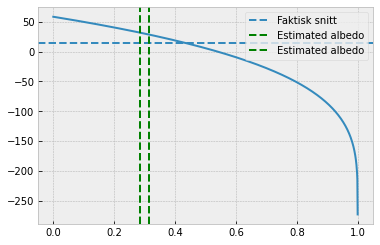

In [ ]:
plt.plot(alphas, T_with_albedo_and_green(alphas))
plt.axhline(y = EarthAverage, linestyle = '--', label='Faktisk snitt') #plotter faktisk snitt temperatur
#plt.axvline(x=0.5, linestyle = '--',c='red', label='Snowball earth')
#plt.scatter(albedo_true, T_with_albedo_and_green(albedo_true), label='estimert temperatur') # plotter punktet med estimert snitt temperatur

plt.axvline(x=albedo_true*(1+albed_un), linestyle = '--',c='green', label='Estimated albedo')
plt.axvline(x=albedo_true*(1-albed_un), linestyle = '--',c='green', label='Estimated albedo')

plt.legend()
plt.show()

# Begrenset drivhuseffekt
Hvis vi ikke antar at atmosfæren absorberer all sort - legeme stråling fra jorden, kan vi heller skrive strålingsbalansen slik:

$$ 2  \delta T_a^4 =\beta\delta T_j^4  $$

Der $\beta$ er prosent stråling absorbert av atmosfæren. Modellen blir da slik:
$$ T_j =\left(\frac{I-I\alpha}{2\beta\delta}\right)^{1/4} $$

In [20]:
def T_with_albedo_and_green(alpha=0, beta=1, I=Itrue):
    return ((I - I*alpha)*beta/(2*delta))**0.25 + Kelvin

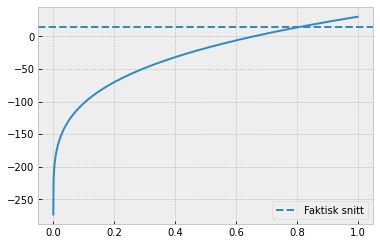

In [ ]:
betas = np.linspace(0,1,1000)
plt.plot(betas, T_with_albedo_and_green(alpha=0.3, beta=betas))
plt.axhline(y = EarthAverage, linestyle = '--', label='Faktisk snitt') #plotter faktisk snitt temperatur
#plt.axvline(x=0.5, linestyle = '--',c='red', label='Snowball earth')
#plt.scatter(albedo_true, T_with_albedo_and_green(albedo_true), label='estimert temperatur') # plotter punktet med estimert snitt temperatur

plt.legend()
plt.show()

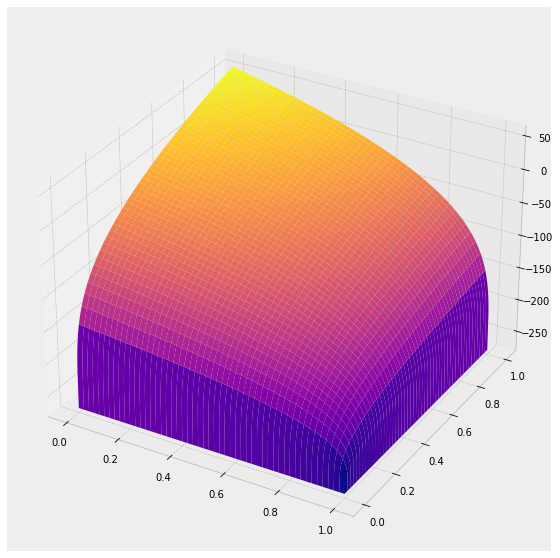

In [53]:
X = np.linspace(0,1,1000)
Y = np.linspace(0,1,1000)
X, Y = np.meshgrid(X, Y)
Z = T_with_albedo_and_green(alpha=X, beta=Y)

H = np.ones((1000,1000))*EarthAverage


fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10,10))
ax.plot_surface(X, Y, Z, cmap="plasma", linewidth=0, zorder=0)


In [64]:
def const_temp_curve(alpha, temp=EarthAverage+Kelvin, I=Itrue):
    # 0 <= alpha <= 1
    res = (I - I*alpha)/(2*delta*temp**4)
    return res

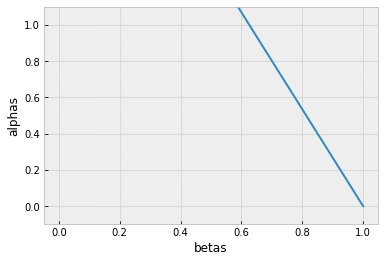

In [65]:
betas = np.linspace(0, 1, 1000)
plt.plot(betas, const_temp_curve(alphas))
plt.ylim([-0.1, 1.1])
plt.ylabel('alphas')
plt.xlabel('betas')
plt.show()